# Лабораторная работа
## Дерево решений — регрессор

В данной работе рассматривается применение дерева решений для решения задачи регрессии. Дерево решений последовательно разбивает объекты на группы по значениям признаков так, чтобы внутри каждой группы целевая переменная была как можно более однородной. В листьях дерева находится прогнозируемое числовое значение. Преимуществом метода является наглядность и способность учитывать нелинейные зависимости между признаками и целевой переменной.

## 1. Используемые библиотеки

В работе используются библиотеки `pandas` для обработки таблиц, `numpy` для численных операций, `matplotlib` и `seaborn` для построения графиков, а также `scikit-learn` для загрузки датасета, разделения выборки, обучения модели и расчёта метрик качества.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")


## 2. Описание датасета

Для лабораторной работы используется датасет `Diabetes` из библиотеки `scikit-learn`. Он содержит медицинские признаки пациентов и целевую переменную, которую нужно предсказать. Это регрессионный датасет, то есть модель должна предсказывать числовое значение. В наборе данных 10 признаков, поэтому он подходит под условие задачи о многопризнаковой регрессии.

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print("Размер таблицы:", df.shape)
print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nПервые 5 строк датасета:")
df.head()


Размер таблицы: (442, 11)

Названия столбцов:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Первые 5 строк датасета:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 3. Краткая информация о признаках

В датасете содержатся числовые признаки пациентов: возраст, пол, индекс массы тела, артериальное давление и показатели анализа крови. Целевая переменная называется `target` и является числовой, поэтому задача относится к регрессии.

In [3]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
df.describe()


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Статистическое описание числовых признаков:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## 4. Предобработка данных

Так как датасет уже подготовлен и все признаки являются числовыми, сложная предобработка здесь не требуется. На данном этапе выполняется проверка пропусков, затем признаки отделяются от целевой переменной.

In [4]:
print("Количество пропусков по столбцам:")
df.isnull().sum()


Количество пропусков по столбцам:


age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print("Размер матрицы признаков:", X.shape)
print("Размер целевой переменной:", y.shape)


Размер матрицы признаков: (442, 10)
Размер целевой переменной: (442,)


## 5. Тепловая карта корреляций

Тепловая карта показывает коэффициенты корреляции между признаками и целевой переменной. Корреляция — это показатель силы и направления линейной связи между величинами. Значения ближе к 1 указывают на прямую связь, ближе к -1 — на обратную, а значения около 0 говорят о слабой линейной связи.

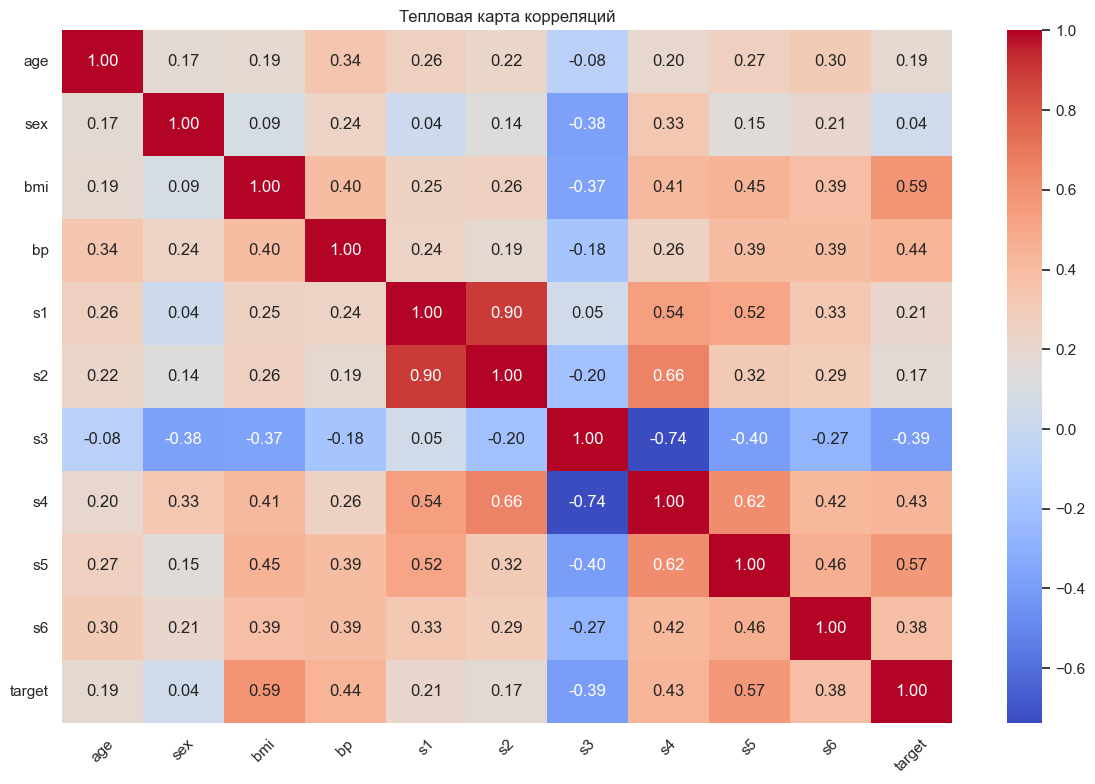

In [6]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Тепловая карта корреляций")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Разделение данных на обучающую и тестовую выборки

Датасет разделяется на две части: 80% данных используются для обучения модели, а 20% — для проверки качества работы на новых данных.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (353, 10)
Размер тестовой выборки: (89, 10)


## 7. Обучение модели дерева решений для регрессии

Создаётся и обучается модель `DecisionTreeRegressor`. Параметр `max_depth` ограничивает максимальную глубину дерева, что помогает сдерживать переобучение.

In [10]:
tree_reg = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_reg.fit(X_train, y_train)

print("Модель обучена.")


Модель обучена.


## 8. Построение прогнозов

После обучения модель используется для предсказания значений целевой переменной на тестовой выборке.

In [11]:
y_pred = tree_reg.predict(X_test)

results = pd.DataFrame({
    "Реальное значение": y_test.values,
    "Предсказанное значение": y_pred
})

print("Первые 10 прогнозов:")
results.head(10)


Первые 10 прогнозов:


,Реальное значение,Предсказанное значение
0,219.0,175.333333
1,70.0,182.773333
2,202.0,175.333333
3,230.0,241.200000
4,111.0,121.859375
5,84.0,90.333333
6,242.0,203.500000
7,272.0,241.200000
8,94.0,134.809524
9,96.0,182.773333


## 9. Оценка качества модели

Для оценки качества используются следующие метрики:

- `MSE` — среднеквадратичная ошибка;
- `MAE` — средняя абсолютная ошибка;
- `R2` — коэффициент детерминации.

Чем меньше значения MSE и MAE, тем лучше. Чем ближе R2 к 1, тем лучше модель объясняет зависимость в данных.

In [12]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")


MSE: 3568.9653
MAE: 47.0454
R2: 0.3264


## 10. Визуализация результатов

Ниже строятся графики, позволяющие наглядно оценить качество работы модели.

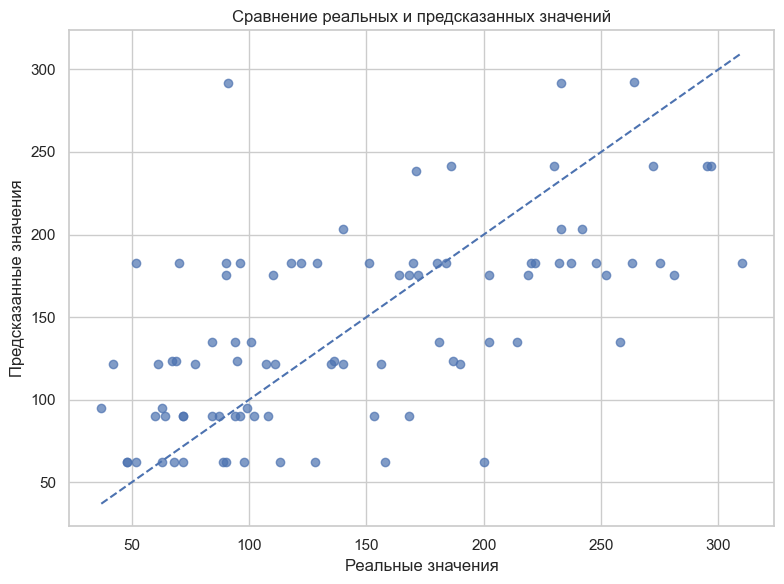

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение реальных и предсказанных значений")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.tight_layout()
plt.show()


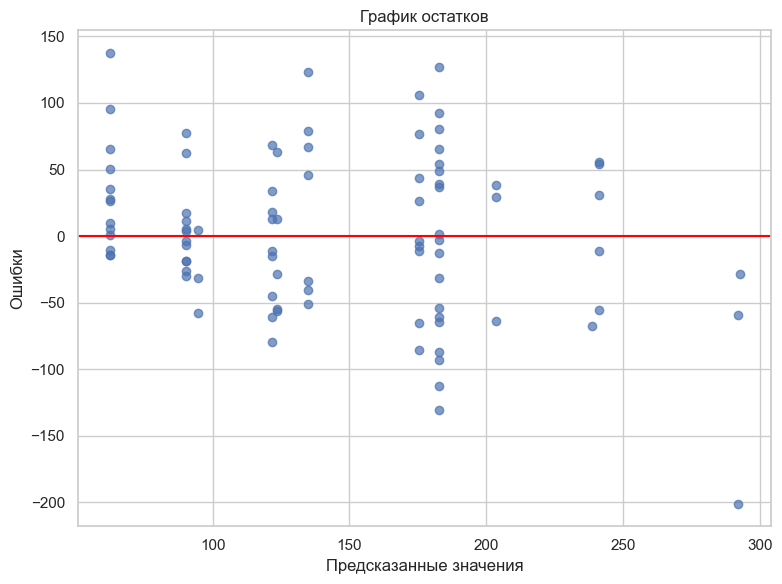

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color="red")
plt.xlabel("Предсказанные значения")
plt.ylabel("Ошибки")
plt.title("График остатков")
plt.tight_layout()
plt.show()


## 11. Визуализация дерева решений

Дерево решений удобно тем, что его структуру можно изобразить графически. Это помогает понять, по каким признакам и порогам модель делает разбиения.

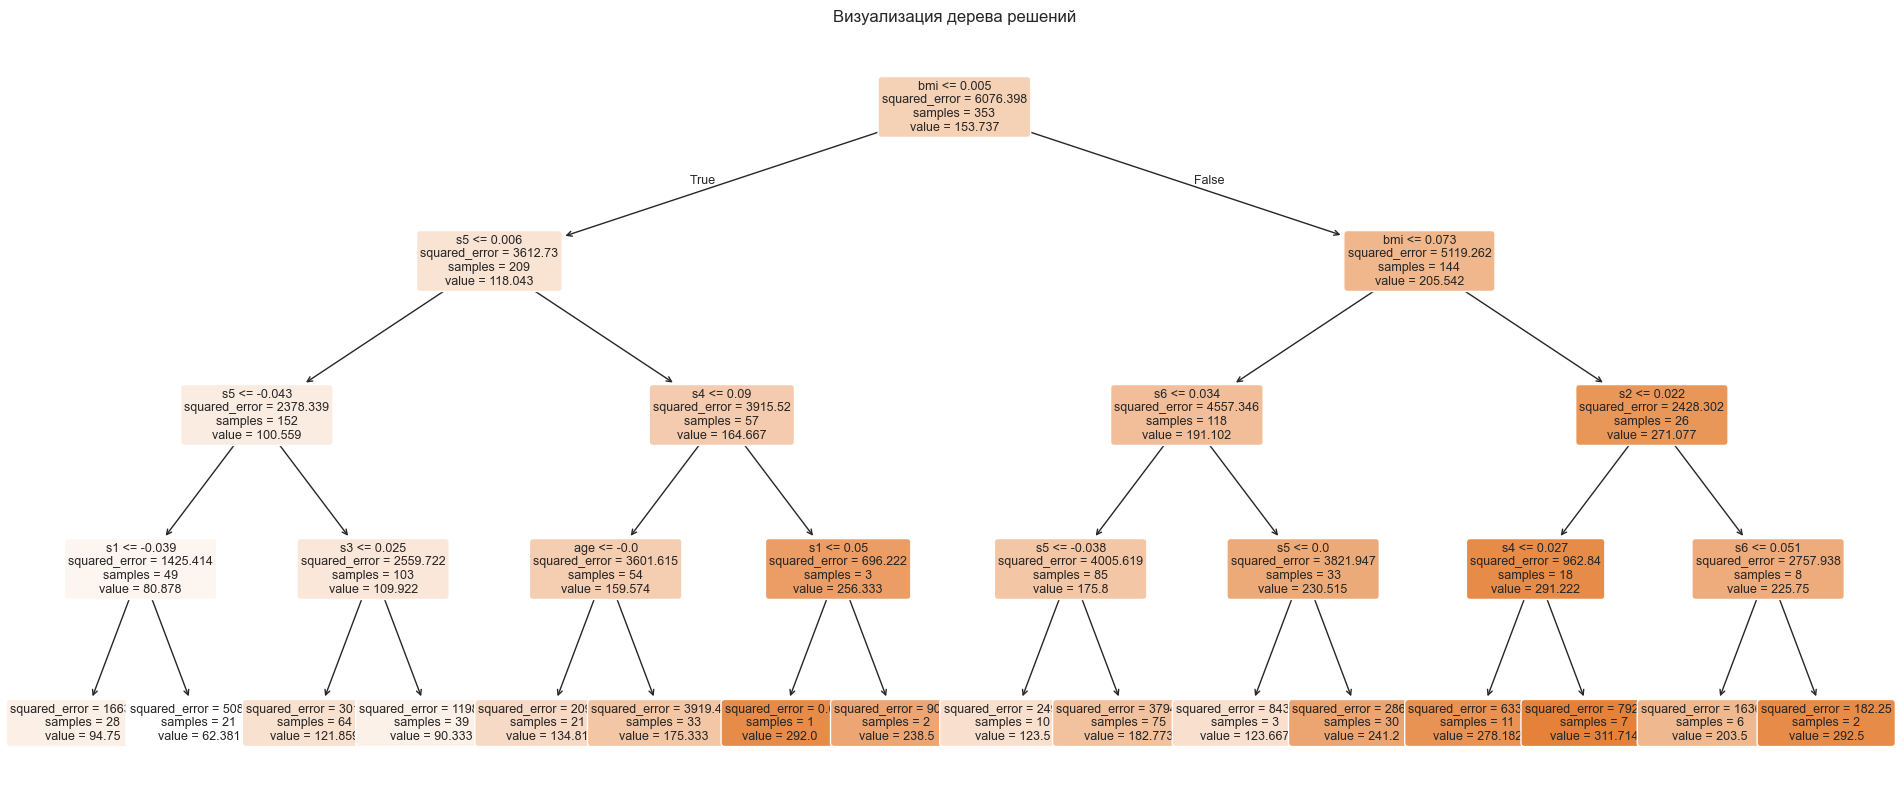

In [15]:
plt.figure(figsize=(24, 10))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Визуализация дерева решений")
plt.show()


## 12. Вывод

В ходе лабораторной работы был изучен метод дерева решений для регрессии. Был использован многопризнаковый датасет, выполнена проверка данных, построена тепловая карта корреляций, обучена модель и оценено качество её работы с помощью метрик MSE, MAE и R2. Также были построены графики сравнения реальных и предсказанных значений, график остатков и визуализация самого дерева. Метод показал, что дерево решений может использоваться для решения задач регрессии, но его качество сильно зависит от параметров модели, например от глубины дерева.